# Notebook 05 — DiT Model Evaluation

**Training is done via the CLI script — this notebook is evaluation-only.**

```bash
# Train DiT (3-stage: head-only → top-2 blocks → full fine-tune)
python -m src.train.train_dit --config configs/dit.yaml
```

After training, run all cells below to get full metrics and plots for **train / val / test** across all three training stages.

In [1]:
import sys, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.special import expit

# ── project root on path ─────────────────────────────────────────────────
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.metrics import compute_metrics, compute_per_institution_metrics, compute_ece
from src.utils.visualization import (
    plot_confusion_matrix, plot_roc_curve, plot_pr_curve,
    plot_calibration_curve, plot_per_institution_metrics,
    plot_score_distribution,
)

# ── paths ─────────────────────────────────────────────────────────────────
CKPT_DIR  = ROOT / 'checkpoints' / 'dit'
LOG_DIR   = ROOT / 'logs'        / 'dit'
PLOTS_DIR = ROOT / 'plots'       / 'dit'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT_PATH = CKPT_DIR / 'best_model.pt'
CAL_PATH       = CKPT_DIR / 'calibrator.pkl'

print(f'ROOT            : {ROOT}')
print(f'Best checkpoint : {BEST_CKPT_PATH}  exists={BEST_CKPT_PATH.exists()}')
print(f'Calibrator      : {CAL_PATH}        exists={CAL_PATH.exists()}')

ROOT            : /Users/idan/projects/sandbox/for_tal
Best checkpoint : /Users/idan/projects/sandbox/for_tal/checkpoints/dit/best_model.pt  exists=True
Calibrator      : /Users/idan/projects/sandbox/for_tal/checkpoints/dit/calibrator.pkl        exists=True


## 1. Three-Stage Training History — Loss & F1 Curves

Loaded 156 log entries from dit.json


,epoch,phase,loss,f1,precision_safe,recall_risky,false_safe_rate,review_rate,roc_auc,pr_auc,ece,T_low,T_high
0,1,stage1/train,0.604710,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,stage1/val,0.507100,0.820896,0.973333,0.000000,0.035088,0.506579,0.922992,0.832906,0.208460,0.233899,0.616950
2,2,stage1/train,0.548933,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,stage1/val,0.429324,0.833333,0.974026,0.754386,0.035088,0.151316,0.951062,0.916089,0.068549,0.304609,0.652305
4,3,stage1/train,0.515917,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


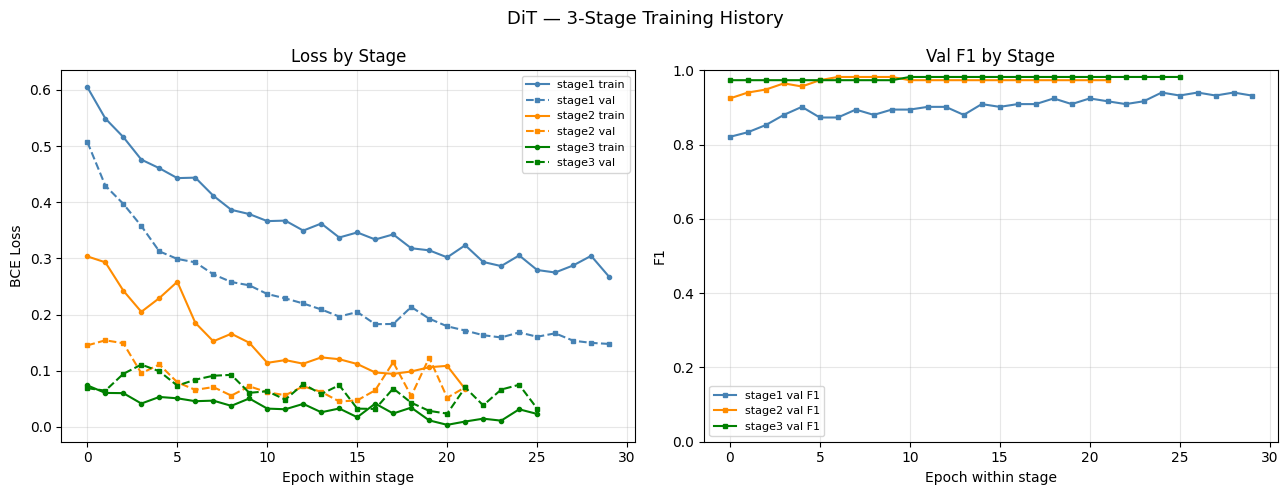

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_training_curves.png


In [2]:
log_path = LOG_DIR / 'dit.json'

if log_path.exists():
    with open(log_path) as f:
        records = json.load(f)
    log_df = pd.DataFrame(records) if records else None
    if log_df is not None:
        print(f'Loaded {len(log_df)} log entries from {log_path.name}')
        display(log_df.head())
    else:
        print('Log file is empty — re-run train_dit.py with the updated script to populate it.')
else:
    log_df = None
    print(f'Log not found at {log_path}. Run train_dit.py first.')


def plot_dit_training_curves(log_df: pd.DataFrame) -> None:
    """Plot 3-stage training curves.

    Supports two log formats:
      New:    phase = 'stage1/train', 'stage1/val', 'stage2/train', ...
      Legacy: phase = 'train', 'val'
    """
    if 'phase' not in log_df.columns:
        print('  Log has no phase column — skipping training curves.')
        return

    stages = ['stage1', 'stage2', 'stage3']
    stage_colors = {'stage1': 'steelblue', 'stage2': 'darkorange', 'stage3': 'green'}
    phases = log_df['phase'].unique().tolist()
    new_format = any('/' in p for p in phases)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('DiT — 3-Stage Training History', fontsize=13)

    if new_format:
        for stage in stages:
            tr = log_df[log_df['phase'] == f'{stage}/train'].sort_values('epoch').reset_index(drop=True)
            vl = log_df[log_df['phase'] == f'{stage}/val'  ].sort_values('epoch').reset_index(drop=True)
            c = stage_colors.get(stage, 'gray')
            if len(tr) > 0 and 'loss' in tr.columns:
                axes[0].plot(range(len(tr)), tr['loss'], color=c, linestyle='-',  marker='o', ms=3, label=f'{stage} train')
            if len(vl) > 0 and 'loss' in vl.columns:
                axes[0].plot(range(len(vl)), vl['loss'], color=c, linestyle='--', marker='s', ms=3, label=f'{stage} val')
            if len(vl) > 0 and 'f1' in vl.columns:
                axes[1].plot(range(len(vl)), vl['f1'],  color=c, linestyle='-',  marker='s', ms=3, label=f'{stage} val F1')
    else:
        tr = log_df[log_df['phase'] == 'train'].sort_values('epoch').reset_index(drop=True)
        vl = log_df[log_df['phase'] == 'val'  ].sort_values('epoch').reset_index(drop=True)
        if 'loss' in tr.columns: axes[0].plot(range(len(tr)), tr['loss'], label='train', marker='o', ms=3)
        if 'loss' in vl.columns: axes[0].plot(range(len(vl)), vl['loss'], label='val',   marker='s', ms=3)
        if 'f1'   in vl.columns: axes[1].plot(range(len(vl)), vl['f1'],  color='green',  marker='s', ms=3, label='val F1')

    axes[0].set_xlabel('Epoch within stage');  axes[0].set_ylabel('BCE Loss');  axes[0].set_title('Loss by Stage')
    axes[0].legend(fontsize=8);  axes[0].grid(alpha=0.3)
    axes[1].set_xlabel('Epoch within stage');  axes[1].set_ylabel('F1');  axes[1].set_title('Val F1 by Stage')
    axes[1].set_ylim([0, 1]);  axes[1].legend(fontsize=8);  axes[1].grid(alpha=0.3)

    plt.tight_layout()
    out = PLOTS_DIR / 'dit_training_curves.png'
    fig.savefig(out, dpi=150);  plt.show();  print(f'Saved → {out}')


if log_df is not None:
    plot_dit_training_curves(log_df)
else:
    print('No training log available — re-run train_dit.py with the updated script.')

## 2. Load Best Checkpoint — Pre-computed Logits

In [3]:
assert BEST_CKPT_PATH.exists(), (
    f'Checkpoint not found: {BEST_CKPT_PATH}\n'
    f'Run: python -m src.train.train_dit --config configs/dit.yaml'
)

ckpt = torch.load(BEST_CKPT_PATH, map_location='cpu',weights_only=False)
print(f'Checkpoint keys : {list(ckpt.keys())}')
print(f'Model name      : {ckpt.get("model_name", "n/a")}')
print(f'Best stage      : {ckpt.get("best_stage", ckpt.get("stage", "n/a"))}')
print(f'Best epoch      : {ckpt.get("epoch", "n/a")}')
print(f'Val F1          : {ckpt.get("val_f1", "n/a")}')
print(f'Temperature     : {ckpt.get("temperature", "n/a")}')
print(f'Thresholds      : {ckpt.get("thresholds")}')

# ── Check whether this checkpoint has the expanded logits ─────────────────
HAS_LOGITS = all(k in ckpt for k in ('train_logits', 'val_logits', 'test_logits'))
if not HAS_LOGITS:
    print(
        '\n⚠️  This checkpoint was saved with an older version of train_dit.py and '
        'does not contain pre-computed logits for all splits.\n'
        'Re-train with the updated script:\n'
        '  python -m src.train.train_dit --config configs/dit.yaml'
    )

Checkpoint keys : ['epoch', 'stage', 'model_state_dict', 'val_f1', 'metrics', 'thresholds', 'model_name', 'best_stage', 'temperature', 'train_logits', 'train_labels', 'train_metrics', 'val_logits', 'val_labels', 'val_metrics', 'test_logits', 'test_labels', 'test_metrics']
Model name      : microsoft/dit-base
Best stage      : stage2
Best epoch      : 7
Val F1          : 0.9821428571428572
Temperature     : 1.2016042854802647
Thresholds      : {'T_low': 0.8053032026013728, 'T_high': 0.9026516013006864}


In [4]:
# ── If checkpoint has pre-computed logits, use them directly ──────────────
# ── Otherwise, fall back to running inference from the model ──────────────

def calibrate(logits, temperature):
    return expit(np.asarray(logits, dtype=np.float64) / temperature).astype(np.float32)

temperature = float(ckpt.get('temperature', 1.0))
thresholds  = ckpt['thresholds']

if HAS_LOGITS:
    train_logits = np.asarray(ckpt['train_logits'], dtype=np.float32)
    train_labels = np.asarray(ckpt['train_labels'], dtype=np.float32)
    val_logits   = np.asarray(ckpt['val_logits'],   dtype=np.float32)
    val_labels   = np.asarray(ckpt['val_labels'],   dtype=np.float32)
    test_logits  = np.asarray(ckpt['test_logits'],  dtype=np.float32)
    test_labels  = np.asarray(ckpt['test_labels'],  dtype=np.float32)
    print('Loaded pre-computed logits from checkpoint.')
else:
    # ── Fallback: run inference on all splits from the saved weights ──────
    import yaml
    from torch.utils.data import DataLoader
    from src.data.dataset import HallucinationRiskDataset
    from src.models.dit_classifier import DiTClassifier
    from src.utils.device import get_device, prepare_model, prepare_input

    with open(ROOT / 'configs' / 'dit.yaml') as f:
        cfg_inf = yaml.safe_load(f)

    device = get_device('auto')
    model = prepare_model(
        DiTClassifier(model_name=cfg_inf['model']['name'], num_classes=1), device
    )
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    md  = cfg_inf['data'].get('metadata_csv', 'data/metadata.csv')
    rd  = cfg_inf['data'].get('rendered_dir', 'data/rendered_pages')
    bs  = cfg_inf['training']['batch_size']

    import torch.nn as nn
    criterion = nn.BCEWithLogitsLoss()

    def run_inference(split):
        ds = HallucinationRiskDataset(metadata_csv=str(ROOT/md), split=split,
                                      rendered_dir=str(ROOT/rd), augment=False)
        loader = DataLoader(ds, batch_size=bs, shuffle=False, num_workers=0)
        all_logits, all_labels = [], []
        with torch.no_grad():
            for imgs, lbls in loader:
                imgs = prepare_input(imgs, device)
                logits = model(imgs)
                all_logits.extend(logits.cpu().squeeze(1).tolist())
                all_labels.extend(lbls.cpu().squeeze(-1).tolist())
        return np.array(all_logits, dtype=np.float32), np.array(all_labels, dtype=np.float32)

    print('Running inference on train set ...')
    train_logits, train_labels = run_inference('train')
    print('Running inference on val set ...')
    val_logits, val_labels = run_inference('val')
    print('Running inference on test set ...')
    test_logits, test_labels = run_inference('test')
    print('Inference complete.')

train_probs = calibrate(train_logits, temperature)
val_probs   = calibrate(val_logits,   temperature)
test_probs  = calibrate(test_logits,  temperature)

train_probs_raw = calibrate(train_logits, 1.0)
val_probs_raw   = calibrate(val_logits,   1.0)
test_probs_raw  = calibrate(test_logits,  1.0)

print(f'\nSplit sizes — train: {len(train_labels)}  val: {len(val_labels)}  test: {len(test_labels)}')
print(f'Temperature — {temperature:.4f}')
print(f'Thresholds  — T_low={thresholds["T_low"]:.4f}  T_high={thresholds["T_high"]:.4f}')
print(f'  Train — mean={train_probs.mean():.3f}  std={train_probs.std():.3f}')
print(f'  Val   — mean={val_probs.mean():.3f}  std={val_probs.std():.3f}')
print(f'  Test  — mean={test_probs.mean():.3f}  std={test_probs.std():.3f}')

Loaded pre-computed logits from checkpoint.

Split sizes — train: 710  val: 152  test: 152
Temperature — 1.2016
Thresholds  — T_low=0.8053  T_high=0.9027
  Train — mean=0.397  std=0.476
  Val   — mean=0.381  std=0.466
  Test  — mean=0.393  std=0.471


## 3. Comprehensive Metrics Table — Train / Val / Test

In [5]:
metric_rows = {}
for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    m = compute_metrics(labels, probs, thresholds)
    metric_rows[split_name] = m

metrics_df = pd.DataFrame(metric_rows).T
metrics_df.index.name = 'Split'

styled = metrics_df.style \
    .format('{:.4f}', na_rep='—') \
    .background_gradient(cmap='RdYlGn', subset=['f1', 'roc_auc', 'pr_auc', 'precision_safe', 'recall_risky']) \
    .background_gradient(cmap='RdYlGn_r', subset=['false_safe_rate', 'ece'])

print('=== DiT Metrics ===')
display(styled)
print(metrics_df.round(4).to_string())

=== DiT Metrics ===


,f1,precision_safe,recall_risky,false_safe_rate,review_rate,roc_auc,pr_auc,ece
Split,,,,,,,,
Train,0.9888,0.9977,0.9962,0.0038,0.0042,0.9990,0.9983,0.0219
Val,0.9821,0.9794,0.9298,0.0351,0.0132,0.9967,0.9953,0.0281
Test,1.0000,1.0000,0.9649,0.0000,0.0132,1.0000,1.0000,0.0243


           f1  precision_safe  recall_risky  false_safe_rate  review_rate  roc_auc  pr_auc     ece
Split                                                                                             
Train  0.9888          0.9977        0.9962           0.0038       0.0042   0.9990  0.9983  0.0219
Val    0.9821          0.9794        0.9298           0.0351       0.0132   0.9967  0.9953  0.0281
Test   1.0000          1.0000        0.9649           0.0000       0.0132   1.0000  1.0000  0.0243


## 4. Calibration Analysis — ECE Before vs After Temperature Scaling

=== ECE Comparison — T=1.2016 ===


,ECE (uncalibrated),ECE (T=1.202)
Train,0.0211,0.0219
Val,0.0222,0.0281
Test,0.0200,0.0243


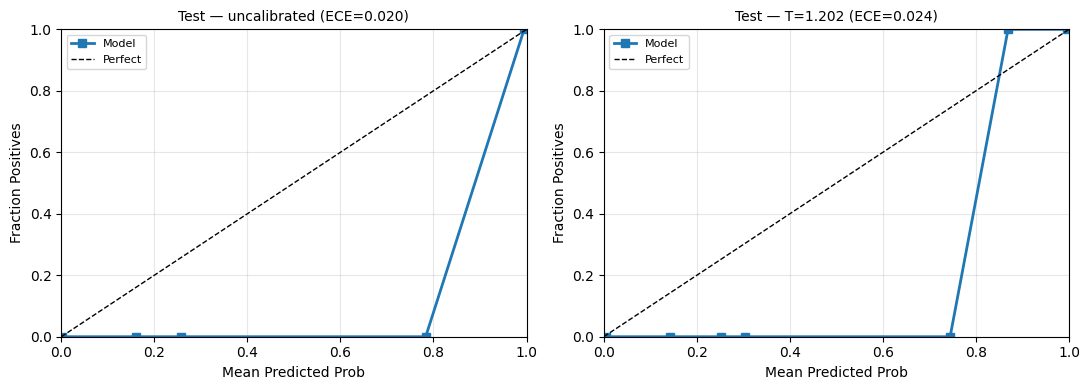

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_calibration.png


In [6]:
ece_table = {}
for split_name, labels, probs_raw, probs_cal in [
    ('Train', train_labels, train_probs_raw, train_probs),
    ('Val',   val_labels,   val_probs_raw,   val_probs),
    ('Test',  test_labels,  test_probs_raw,  test_probs),
]:
    ece_table[split_name] = {
        'ECE (uncalibrated)': compute_ece(labels, probs_raw),
        f'ECE (T={temperature:.3f})': compute_ece(labels, probs_cal),
    }

ece_df = pd.DataFrame(ece_table).T
print(f'=== ECE Comparison — T={temperature:.4f} ===')
display(ece_df.style.format('{:.4f}').background_gradient(cmap='RdYlGn_r'))

from sklearn.calibration import calibration_curve
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, probs, title in [
    (axes[0], test_probs_raw, f'Test — uncalibrated (ECE={compute_ece(test_labels, test_probs_raw):.3f})'),
    (axes[1], test_probs,     f'Test — T={temperature:.3f} (ECE={compute_ece(test_labels, test_probs):.3f})'),
]:
    if len(np.unique(test_labels)) >= 2:
        fop, mpv = calibration_curve(test_labels, probs, n_bins=10, strategy='uniform')
        ax.plot(mpv, fop, 's-', lw=2, label='Model')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
    ax.set_title(title, fontsize=10);  ax.set_xlabel('Mean Predicted Prob');  ax.set_ylabel('Fraction Positives')
    ax.legend(fontsize=8);  ax.set_xlim([0,1]);  ax.set_ylim([0,1]);  ax.grid(alpha=0.3)

plt.tight_layout()
out = PLOTS_DIR / 'dit_calibration.png'
fig.savefig(out, dpi=150);  plt.show();  print(f'Saved → {out}')

## 5. Confusion Matrix

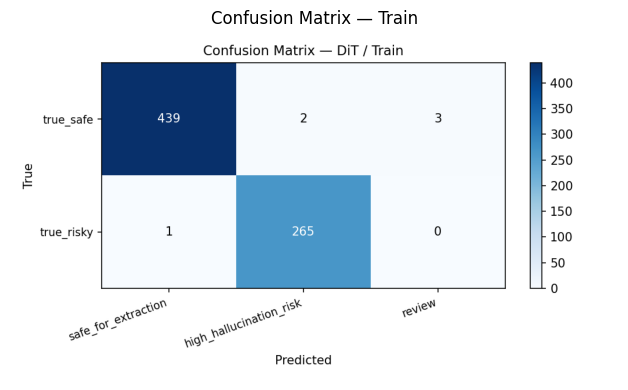

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_confusion_train.png


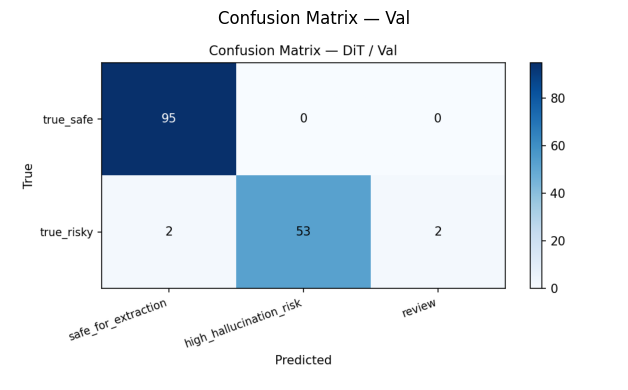

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_confusion_val.png


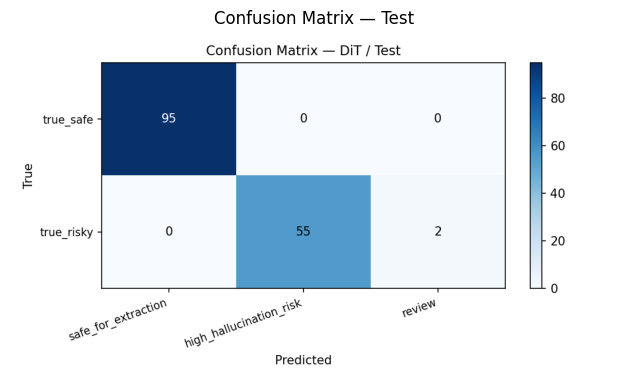

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_confusion_test.png


In [7]:
def apply_thresholds(probs, thresholds):
    t_low, t_high = thresholds['T_low'], thresholds['T_high']
    return np.where(probs < t_low, 0, np.where(probs > t_high, 1, 2)).astype(int)

for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    pred_ternary = apply_thresholds(probs, thresholds)
    out = PLOTS_DIR / f'dit_confusion_{split_name.lower()}.png'
    plot_confusion_matrix(
        labels, pred_ternary, str(out),
        title=f'Confusion Matrix — DiT / {split_name}'
    )
    img = plt.imread(str(out))
    plt.figure(figsize=(7, 4));  plt.imshow(img);  plt.axis('off')
    plt.title(f'Confusion Matrix — {split_name}');  plt.tight_layout();  plt.show()
    print(f'Saved → {out}')

## 6. ROC & PR Curves — Train / Val / Test

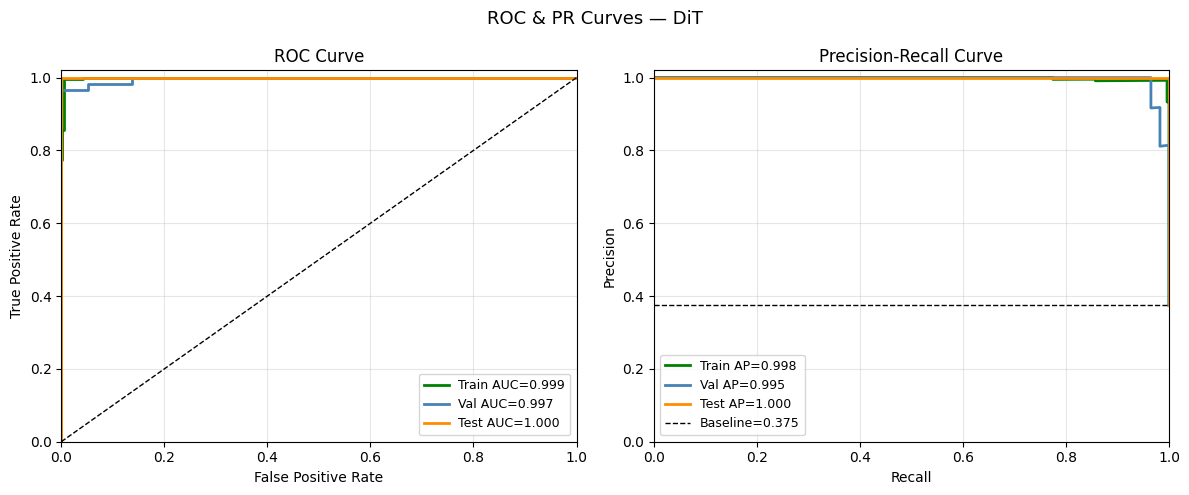

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_roc_pr.png


In [8]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ROC & PR Curves — DiT', fontsize=13)

colors = {'Val': 'steelblue', 'Test': 'darkorange', 'Train': 'green'}

ax = axes[0]
for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    if len(np.unique(labels)) >= 2:
        fpr, tpr, _ = roc_curve(labels, probs)
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, color=colors[split_name], label=f'{split_name} AUC={roc_auc_val:.3f}')
ax.plot([0,1],[0,1],'k--',lw=1);  ax.set_xlim([0,1]);  ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate');  ax.set_ylabel('True Positive Rate');  ax.set_title('ROC Curve')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

ax = axes[1]
for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    if len(np.unique(labels)) >= 2:
        precision, recall, _ = precision_recall_curve(labels, probs)
        ap = average_precision_score(labels, probs)
        ax.plot(recall, precision, lw=2, color=colors[split_name], label=f'{split_name} AP={ap:.3f}')
baseline = test_labels.mean()
ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.3f}')
ax.set_xlim([0,1]);  ax.set_ylim([0,1.02])
ax.set_xlabel('Recall');  ax.set_ylabel('Precision');  ax.set_title('Precision-Recall Curve')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

plt.tight_layout()
out = PLOTS_DIR / 'dit_roc_pr.png'
fig.savefig(out, dpi=150);  plt.show();  print(f'Saved → {out}')

## 7. Score Distribution — All Splits

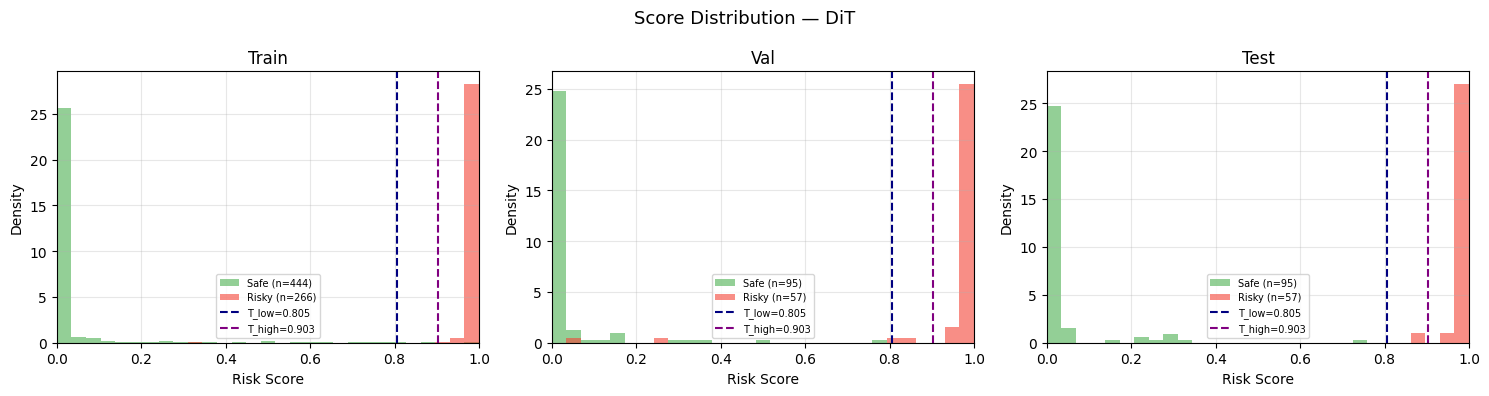

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_score_dist.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle('Score Distribution — DiT', fontsize=13)
bins = np.linspace(0, 1, 30)

for ax, split_name, labels, probs in [
    (axes[0], 'Train', train_labels, train_probs),
    (axes[1], 'Val',   val_labels,   val_probs),
    (axes[2], 'Test',  test_labels,  test_probs),
]:
    safe_sc  = probs[labels == 0]
    risky_sc = probs[labels == 1]
    if len(safe_sc)  > 0: ax.hist(safe_sc,  bins=bins, alpha=0.6, color='#4caf50', label=f'Safe (n={len(safe_sc)})',  density=True)
    if len(risky_sc) > 0: ax.hist(risky_sc, bins=bins, alpha=0.6, color='#f44336', label=f'Risky (n={len(risky_sc)})', density=True)
    t_low, t_high = thresholds['T_low'], thresholds['T_high']
    ax.axvline(t_low,  color='navy',   linestyle='--', lw=1.5, label=f'T_low={t_low:.3f}')
    ax.axvline(t_high, color='purple', linestyle='--', lw=1.5, label=f'T_high={t_high:.3f}')
    ax.set_title(split_name);  ax.set_xlabel('Risk Score');  ax.set_ylabel('Density')
    ax.legend(fontsize=7);  ax.set_xlim([0,1]);  ax.grid(alpha=0.3)

plt.tight_layout()
out = PLOTS_DIR / 'dit_score_dist.png'
fig.savefig(out, dpi=150);  plt.show();  print(f'Saved → {out}')

## 8. Per-Institution Breakdown

In [10]:
import yaml
from src.data.dataset import HallucinationRiskDataset

with open(ROOT / 'configs' / 'dit.yaml') as f:
    cfg = yaml.safe_load(f)

metadata_csv = cfg['data'].get('metadata_csv', 'data/metadata.csv')
rendered_dir = cfg['data'].get('rendered_dir', 'data/rendered_pages')

val_ds  = HallucinationRiskDataset(metadata_csv=str(ROOT/metadata_csv), split='val',  rendered_dir=str(ROOT/rendered_dir), augment=False)
test_ds = HallucinationRiskDataset(metadata_csv=str(ROOT/metadata_csv), split='test', rendered_dir=str(ROOT/rendered_dir), augment=False)

def get_institutions(ds):
    if 'institution' in ds.df.columns:
        return ds.df['institution'].values
    return np.array(['unknown'] * len(ds))

val_inst  = get_institutions(val_ds)
test_inst = get_institutions(test_ds)

per_inst_val  = compute_per_institution_metrics(val_labels,  val_probs,  val_inst,  thresholds)
per_inst_test = compute_per_institution_metrics(test_labels, test_probs, test_inst, thresholds)

print('=== Per-Institution — Val ===')
display(per_inst_val.style.format('{:.4f}', subset=per_inst_val.select_dtypes('float').columns).background_gradient(cmap='RdYlGn'))

print('\n=== Per-Institution — Test ===')
display(per_inst_test.style.format('{:.4f}', subset=per_inst_test.select_dtypes('float').columns).background_gradient(cmap='RdYlGn'))

=== Per-Institution — Val ===


,institution,n_samples,f1,recall_risky,false_safe_rate,review_rate
0,questionnaires,57,0.9821,0.9298,0.0351,0.0351
1,regular_docs,95,0.0000,nan,nan,0.0000



=== Per-Institution — Test ===


,institution,n_samples,f1,recall_risky,false_safe_rate,review_rate
0,questionnaires,57,1.0000,0.9649,0.0000,0.0351
1,regular_docs,95,0.0000,nan,nan,0.0000


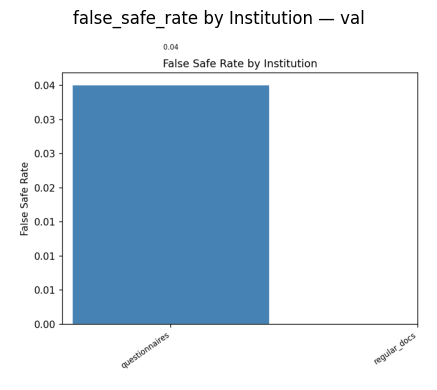

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_per_institution_false_safe_rate_val.png


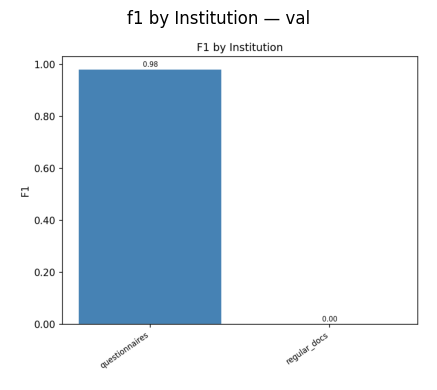

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_per_institution_f1_val.png


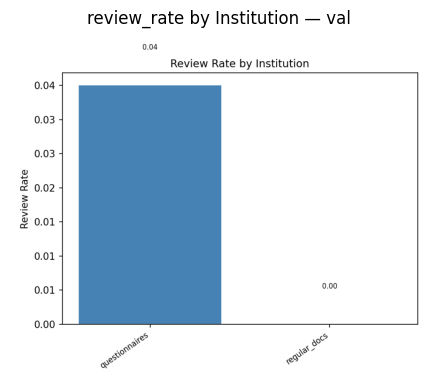

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_per_institution_review_rate_val.png


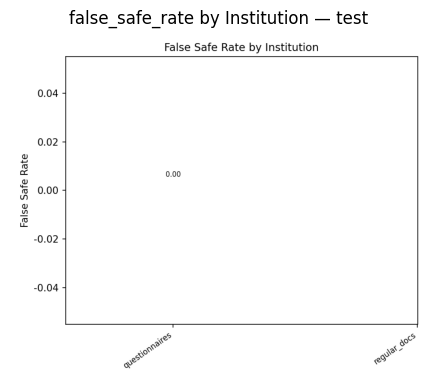

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_per_institution_false_safe_rate_test.png


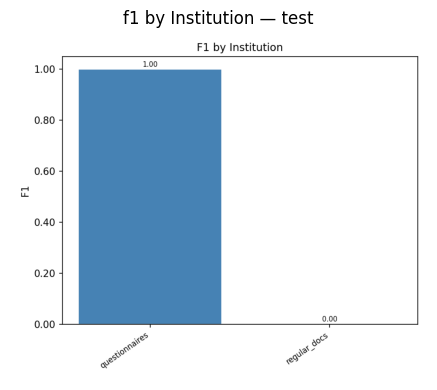

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_per_institution_f1_test.png


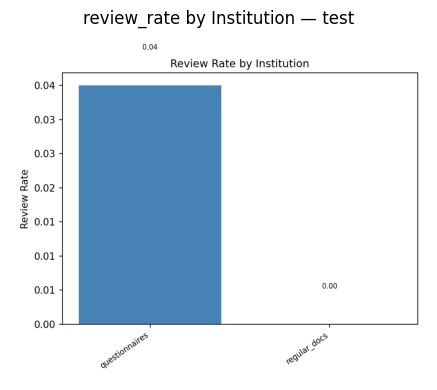

Saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_per_institution_review_rate_test.png


In [11]:
for split_name, df in [('val', per_inst_val), ('test', per_inst_test)]:
    for metric in ['false_safe_rate', 'f1', 'review_rate']:
        if metric in df.columns:
            out = PLOTS_DIR / f'dit_per_institution_{metric}_{split_name}.png'
            plot_per_institution_metrics(df, metric, str(out))
            img = plt.imread(str(out))
            plt.figure(figsize=(8, 4));  plt.imshow(img);  plt.axis('off')
            plt.title(f'{metric} by Institution — {split_name}');  plt.tight_layout();  plt.show()
            print(f'Saved → {out}')

## 9. Comparison: DiT vs Best Baseline (if available)

In [12]:
baseline_ckpt_path = ROOT / 'checkpoints' / 'baseline' / 'best_resnet50.pt'

if baseline_ckpt_path.exists():
    baseline_ckpt = torch.load(baseline_ckpt_path, map_location='cpu',weights_only=False)
    b_temp   = float(baseline_ckpt.get('temperature', 1.0))
    b_thresh = baseline_ckpt['thresholds']

    b_train_probs = calibrate(baseline_ckpt['train_logits'], b_temp)
    b_val_probs   = calibrate(baseline_ckpt['val_logits'],   b_temp)
    b_test_probs  = calibrate(baseline_ckpt['test_logits'],  b_temp)

    dit_name = ckpt.get('model_name', 'dit')
    comparison_rows = {}
    for model_label, tr_p, v_p, te_p, thresh in [
        (f'DiT ({dit_name})',  train_probs,   val_probs,   test_probs,   thresholds),
        ('ResNet50 (baseline)', b_train_probs, b_val_probs, b_test_probs, b_thresh),
    ]:
        for split_name, labels, probs in [
            ('Train', train_labels, tr_p),
            ('Val',   val_labels,   v_p),
            ('Test',  test_labels,  te_p),
        ]:
            m = compute_metrics(labels, probs, thresh)
            comparison_rows[f'{model_label}/{split_name}'] = m

    cmp_df = pd.DataFrame(comparison_rows).T
    cmp_df.index.name = 'Model/Split'
    print('=== DiT vs Baseline Comparison ===')
    display(cmp_df.style.format('{:.4f}', na_rep='—').background_gradient(cmap='RdYlGn', subset=['f1', 'roc_auc']))
else:
    print(f'Baseline checkpoint not found at {baseline_ckpt_path}.')
    print('Run notebook 04 (train ResNet50) first to enable comparison.')

=== DiT vs Baseline Comparison ===


,f1,precision_safe,recall_risky,false_safe_rate,review_rate,roc_auc,pr_auc,ece
Model/Split,,,,,,,,
DiT (microsoft/dit-base)/Train,0.9888,0.9977,0.9962,0.0038,0.0042,0.9990,0.9983,0.0219
DiT (microsoft/dit-base)/Val,0.9821,0.9794,0.9298,0.0351,0.0132,0.9967,0.9953,0.0281
DiT (microsoft/dit-base)/Test,1.0000,1.0000,0.9649,0.0000,0.0132,1.0000,1.0000,0.0243
ResNet50 (baseline)/Train,0.9848,0.9844,0.9662,0.0263,0.0028,0.9998,0.9997,0.0041
ResNet50 (baseline)/Val,0.9821,0.9794,0.9298,0.0351,0.0132,0.9989,0.9983,0.0186
ResNet50 (baseline)/Test,0.9730,0.9694,0.9298,0.0526,0.0066,1.0000,1.0000,0.0133


## 10. Summary Export

In [13]:
model_name = ckpt.get('model_name', 'dit')
best_stage = ckpt.get('best_stage', ckpt.get('stage', 'n/a'))

summary_rows = []
for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    m = compute_metrics(labels, probs, thresholds)
    row = {
        'model': model_name, 'best_stage': best_stage,
        'split': split_name, 'temperature': temperature, **m,
        'T_low': thresholds['T_low'], 'T_high': thresholds['T_high'],
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
out_csv = PLOTS_DIR / 'dit_summary.csv'
summary_df.to_csv(out_csv, index=False)
print(f'Summary saved → {out_csv}')
display(summary_df.style.format('{:.4f}', subset=summary_df.select_dtypes('float').columns))

Summary saved → /Users/idan/projects/sandbox/for_tal/plots/dit/dit_summary.csv


,model,best_stage,split,temperature,f1,precision_safe,recall_risky,false_safe_rate,review_rate,roc_auc,pr_auc,ece,T_low,T_high
0,microsoft/dit-base,stage2,Train,1.2016,0.9888,0.9977,0.9962,0.0038,0.0042,0.9990,0.9983,0.0219,0.8053,0.9027
1,microsoft/dit-base,stage2,Val,1.2016,0.9821,0.9794,0.9298,0.0351,0.0132,0.9967,0.9953,0.0281,0.8053,0.9027
2,microsoft/dit-base,stage2,Test,1.2016,1.0000,1.0000,0.9649,0.0000,0.0132,1.0000,1.0000,0.0243,0.8053,0.9027
